# Notebook 1 — Pre-processing
## Bangla-Hindi-English Code-Switched Sentiment Analysis

**Training data**: `md-nishat-008/Code-Mixed-Sentiment-Analysis-Dataset` — 100k synthetic code-mixed samples (pre-split: 60k train / 20k val / 20k test, balanced 33.3% each class)

1. Load and clean dataset
2. Run EDA and script-level analysis
3. OOV analysis
4. Save cleaned CSVs

## Install Dependencies

In [1]:
!pip install datasets pandas numpy matplotlib seaborn scikit-learn -q

## Imports

In [16]:
import re
import random
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

LABEL2ID = {"Positive": 0, "Negative": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

## Load Training Dataset

`md-nishat-008/Code-Mixed-Sentiment-Analysis-Dataset` was created by the SentMix-3L authors.
It starts from 100k Amazon reviews, converts star ratings to Positive/Neutral/Negative,
then synthetically injects Bangla and Hindi tokens using code-mixing algorithms.
It comes pre-split into train (60k) / val (20k) / test (20k) with perfectly balanced classes.

In [17]:
from datasets import load_dataset

# ── Load synthetic training dataset ──────────────────────────────────────
train_hf = load_dataset("md-nishat-008/Code-Mixed-Sentiment-Analysis-Dataset")

print(f"Splits     : {list(train_hf.keys())}")
print(f"Features   : {train_hf['train'].features}")
print(f"Train size : {len(train_hf['train'])}")
print(f"Val size   : {len(train_hf['validation'])}")
print(f"Test size  : {len(train_hf['test'])}")

df_train_raw = pd.DataFrame(train_hf["train"])
df_val_raw   = pd.DataFrame(train_hf["validation"])
df_test_raw  = pd.DataFrame(train_hf["test"])

print(f"\nColumns : {df_train_raw.columns.tolist()}")
df_train_raw.head(3)

Splits     : ['train', 'validation', 'test']
Features   : {'label': Value('string'), 'text': Value('string')}
Train size : 59999
Val size   : 20000
Test size  : 20000

Columns : ['label', 'text']


,label,text
0,Negative,DO NOT let the blu ray symbol on the box fool ...
1,Neutral,আমার কোন ভাগ্য ছিল না trying to recover my फ़ा...
2,Negative,यह बात वाकई में उलझ सकती है your computer. Che...


In [19]:
# ── Use half the dataset to save compute ─────────────────────────────────
# Reduces 60k/20k/20k → 30k/10k/10k.

from sklearn.model_selection import train_test_split

df_train_raw, _ = train_test_split(df_train_raw, train_size=0.5,
                                    stratify=df_train_raw["label"], random_state=SEED)
df_val_raw,   _ = train_test_split(df_val_raw,   train_size=0.5,
                                    stratify=df_val_raw["label"],   random_state=SEED)
df_test_raw,  _ = train_test_split(df_test_raw,  train_size=0.5,
                                    stratify=df_test_raw["label"],  random_state=SEED)

print("Using half the dataset")
print(f"  Train : {len(df_train_raw):,}  {dict(df_train_raw['label'].value_counts().sort_index())}")
print(f"  Val   : {len(df_val_raw):,}    {dict(df_val_raw['label'].value_counts().sort_index())}")
print(f"  Test  : {len(df_test_raw):,}   {dict(df_test_raw['label'].value_counts().sort_index())}")

Using half the dataset

  Train : 29,999  {'Negative': np.int64(10000), 'Neutral': np.int64(10000), 'Positive': np.int64(9999)}
  Val   : 10,000   {'Negative': np.int64(3333), 'Neutral': np.int64(3333), 'Positive': np.int64(3334)}
  Test  : 10,000   {'Negative': np.int64(3333), 'Neutral': np.int64(3333), 'Positive': np.int64(3334)}


## Load Test Dataset (SentMix-3L) for Testing

In [20]:
# ── Load natural test dataset ─────────────────────────────────────────────
sentmix_hf = load_dataset("md-nishat-008/SentMix-3L")
df_sentmix  = pd.DataFrame(sentmix_hf["train"])  # only one split available

print(f"Shape   : {df_sentmix.shape}")
print(f"Columns : {df_sentmix.columns.tolist()}")
df_sentmix.head(3)

Shape   : (1007, 2)
Columns : ['text', 'label']


,text,label
0,I knew it আমি যদি work hard করি I will get pr...,Positive
1,I still can't believe that আমার সবচেয়ে কাছের ...,Positive
2,The সুন্দর sunset has made my বাজে দিন into ...,Positive


## Normalise Labels

In [21]:
def normalise_labels(df, label_col="label"):
    df = df.copy()
    df[label_col] = df[label_col].astype(str).str.strip().str.capitalize()
    df = df[df[label_col].isin(LABEL2ID)].dropna(subset=["text", label_col]).reset_index(drop=True)
    df["label_id"] = df[label_col].map(LABEL2ID)
    return df

df_train_raw = normalise_labels(df_train_raw)
df_val_raw   = normalise_labels(df_val_raw)
df_test_raw  = normalise_labels(df_test_raw)
df_sentmix   = normalise_labels(df_sentmix)

print("Training dataset label distribution:")
print(f"  Train : {dict(Counter(df_train_raw['label']))}")
print(f"  Val   : {dict(Counter(df_val_raw['label']))}")
print(f"  Test  : {dict(Counter(df_test_raw['label']))}")
print(f"\nSentMix-3L: {dict(Counter(df_sentmix['label']))}")

Training dataset label distribution:
  Train : {'Negative': 9999, 'Neutral': 9999, 'Positive': 9997}
  Val   : {'Neutral': 3333, 'Negative': 3332, 'Positive': 3333}
  Test  : {'Neutral': 3333, 'Negative': 3333, 'Positive': 3334}

SentMix-3L: {'Positive': 420, 'Neutral': 234, 'Negative': 353}


## Exploratory Data Analysis

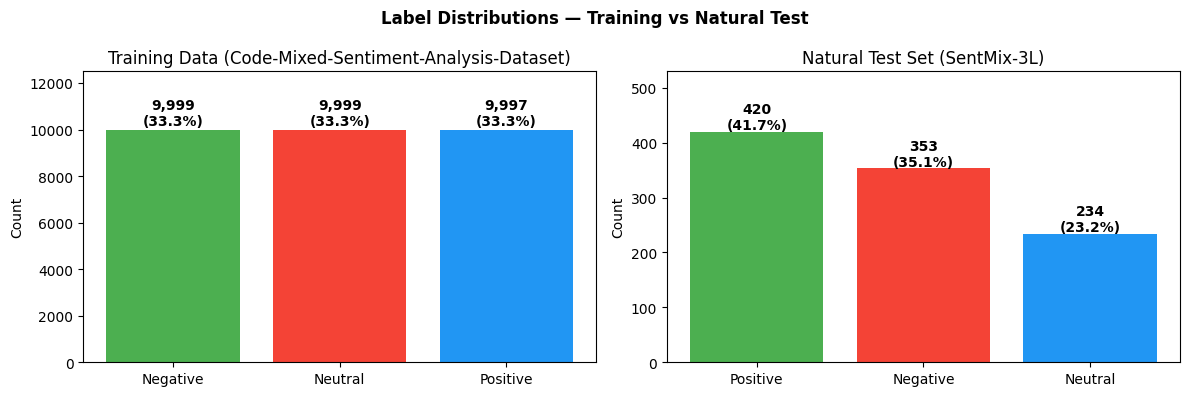

In [26]:
# ── Label distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#4CAF50", "#F44336", "#2196F3"]

# Training data
train_counts = df_train_raw["label"].value_counts()
axes[0].bar(train_counts.index, train_counts.values, color=colors)
axes[0].set_title("Training Data (Code-Mixed-Sentiment-Analysis-Dataset)")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 12500)
for i, v in enumerate(train_counts.values):
    pct = 100 * v / len(df_train_raw)
    axes[0].text(i, v + 200, f"{v:,}\n({pct:.1f}%)", ha="center", fontweight="bold")

# SentMix-3L test set
test_counts = df_sentmix["label"].value_counts()
axes[1].bar(test_counts.index, test_counts.values, color=colors)
axes[1].set_title("Natural Test Set (SentMix-3L)")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 530)
for i, v in enumerate(test_counts.values):
    pct = 100 * v / len(df_sentmix)
    axes[1].text(i, v + 5, f"{v}\n({pct:.1f}%)", ha="center", fontweight="bold")

plt.suptitle("Label Distributions — Training vs Natural Test", fontweight="bold")
plt.tight_layout()
plt.show()

Training data word count stats:
count    29995.0
mean        91.3
std        138.4
min          1.0
25%         21.0
50%         49.0
75%        110.0
max       4497.0

SentMix-3L word count stats:
count    1007.0
mean       88.9
std        19.2
min        36.0
25%        77.0
50%        88.0
75%        99.0
max       188.0


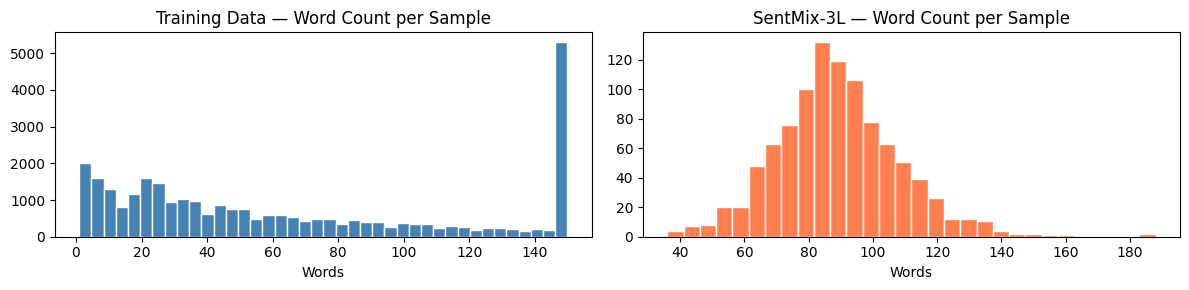

In [27]:
# ── Text length comparison ─────────────────────────────────────────────────
df_train_raw["word_count"] = df_train_raw["text"].str.split().str.len()
df_sentmix["word_count"]   = df_sentmix["text"].str.split().str.len()

print("Training data word count stats:")
print(df_train_raw["word_count"].describe().round(1).to_string())
print("\nSentMix-3L word count stats:")
print(df_sentmix["word_count"].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(df_train_raw["word_count"].clip(upper=150), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Training Data — Word Count per Sample")
axes[0].set_xlabel("Words")
axes[1].hist(df_sentmix["word_count"].clip(upper=200), bins=30, color="coral", edgecolor="white")
axes[1].set_title("SentMix-3L — Word Count per Sample")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

## Language-Aware Pre-processing

| Step | What we do | Why |
|------|-----------|-----|
| Unicode NFC | Normalise composite characters | Ensures `ক` + `া` = `কা` tokenise consistently |
| URLs / @mentions | Remove entirely | Zero sentiment signal |
| #Hashtags | Drop `#`, keep word | `#WeddingJoy` → `WeddingJoy` preserves sentiment |
| Repeated chars | Collapse 4+ → 2 | `loooove` → `loove` |
| OOV words | **Do nothing** | XLM-RoBERTa SentencePiece handles all 3 scripts with zero `<UNK>` |

In [28]:
class CodeSwitchedPreprocessor:
    """
    Language-aware cleaner for Bangla-Hindi-English code-mixed text.
    Preserves all three Unicode script ranges intact.
    Does NOT strip non-ASCII, transliterate, or insert <UNK>.
    """
    RE_BANGLA  = re.compile(r"[\u0980-\u09FF]+")
    RE_HINDI   = re.compile(r"[\u0900-\u097F]+")
    RE_ENGLISH = re.compile(r"[a-zA-Z]+")
    RE_URL     = re.compile(r"https?://\S+|www\.\S+")
    RE_MENTION = re.compile(r"@\w+")
    RE_HASHTAG = re.compile(r"#(\w+)")      # keep the word, drop #
    RE_REPEAT  = re.compile(r"(.)\1{3,}")   # 4+ repeated chars → 2
    RE_CONTROL = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")

    def detect_scripts(self, text):
        tokens = text.split()
        c = {"bangla": 0, "hindi": 0, "english": 0, "other": 0}
        for tok in tokens:
            if   self.RE_BANGLA.search(tok):  c["bangla"]  += 1
            elif self.RE_HINDI.search(tok):   c["hindi"]   += 1
            elif self.RE_ENGLISH.search(tok): c["english"] += 1
            else:                             c["other"]   += 1
        total = max(sum(c.values()), 1)
        return {k: round(v / total, 3) for k, v in c.items()}

    def clean(self, text):
        if not isinstance(text, str):
            return ""
        text = unicodedata.normalize("NFC", text)
        text = self.RE_URL.sub(" ", text)
        text = self.RE_MENTION.sub(" ", text)
        text = self.RE_HASHTAG.sub(r" \1 ", text)
        text = self.RE_REPEAT.sub(r"\1\1", text)
        text = self.RE_CONTROL.sub("", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

pre = CodeSwitchedPreprocessor()

# Demo
demo_cases = [
    "আজকে @user visit করলাম https://t.co/xyz #HappyDay!! খুব bhala laglo!!!",
    "यह फिल्म একদম #Bakwas ছিল @critic woooorst movie ever!",
]
print("=== Pre-processing Demo ===\n")
for raw in demo_cases:
    cleaned = pre.clean(raw)
    print(f"Raw    : {raw}")
    print(f"Cleaned: {cleaned}")
    print(f"Scripts: {pre.detect_scripts(cleaned)}")
    print()

=== Pre-processing Demo ===

Raw    : আজকে @user visit করলাম https://t.co/xyz #HappyDay!! খুব bhala laglo!!!
Cleaned: আজকে visit করলাম HappyDay !! খুব bhala laglo!!!
Scripts: {'bangla': 0.375, 'hindi': 0.0, 'english': 0.5, 'other': 0.125}

Raw    : यह फिल्म একদম #Bakwas ছিল @critic woooorst movie ever!
Cleaned: यह फिल्म একদম Bakwas ছিল woorst movie ever!
Scripts: {'bangla': 0.25, 'hindi': 0.25, 'english': 0.5, 'other': 0.0}



## Apply Cleaning to All Splits

In [29]:
# ── Clean all splits ─────────────────────────────────────────────────────
splits = {
    "train"  : df_train_raw,
    "val"    : df_val_raw,
    "test"   : df_test_raw,
    "sentmix": df_sentmix,
}

for name, df_ in splits.items():
    df_["clean_text"] = df_["text"].apply(pre.clean)
    before = len(df_)
    mask   = df_["clean_text"].str.strip().str.len() > 0
    dropped = before - mask.sum()
    if dropped > 0:
        splits[name] = df_[mask].reset_index(drop=True)
    print(f"{name:10s}: {len(df_):6,} samples  dropped={dropped}")

df_train_raw = splits["train"]
df_val_raw   = splits["val"]
df_test_raw  = splits["test"]
df_sentmix   = splits["sentmix"]

print("\nScript proportions in training data (sample of 2,000):")
sample_scripts = (
    df_train_raw["clean_text"]
    .sample(2000, random_state=SEED)
    .apply(pre.detect_scripts)
    .apply(pd.Series)
)
print(sample_scripts.mean().round(3).to_string())

train     : 29,995 samples  dropped=1
val       :  9,998 samples  dropped=0
test      : 10,000 samples  dropped=0
sentmix   :  1,007 samples  dropped=0

Script proportions in training data (sample of 2,000):
bangla     0.296
hindi      0.360
english    0.328
other      0.016


## OOV Analysis

### Why we do NOT replace OOV with `<UNK>`

XLM-RoBERTa uses SentencePiece with a 250,000-token vocabulary trained on 100 languages.
Any token it cannot match as a whole word is split into sub-word pieces — going to
individual characters if necessary. **Zero `<UNK>` tokens ever appear in model input.**
Replacing rare tokens with `<UNK>` would silently destroy sentiment signal.

In [30]:
# ── OOV analysis on a sample (5k texts for speed) ────────────────────────
sample_texts = df_train_raw["clean_text"].sample(5000, random_state=SEED)
all_tokens   = [tok for text in sample_texts for tok in text.split()]
token_freq   = Counter(all_tokens)
total_unique = len(token_freq)
hapax        = sum(1 for v in token_freq.values() if v == 1)
rare         = sum(1 for v in token_freq.values() if v <= 2)

print(f"Sample size           : 5,000 texts")
print(f"Total unique tokens   : {total_unique:,}")
print(f"Hapax legomena (f=1)  : {hapax:,}  ({100*hapax/total_unique:.1f}%)")
print(f"Rare tokens (f≤2)     : {rare:,}  ({100*rare/total_unique:.1f}%)")
print()
print("Top 10 Bangla tokens :", [(t,f) for t,f in token_freq.most_common() if pre.RE_BANGLA.search(t)][:10])
print("Top 10 Hindi tokens  :", [(t,f) for t,f in token_freq.most_common() if pre.RE_HINDI.search(t)][:10])
print("Top 10 English tokens:", [(t,f) for t,f in token_freq.most_common() if pre.RE_ENGLISH.search(t)][:10])

Sample size           : 5,000 texts
Total unique tokens   : 46,008
Hapax legomena (f=1)  : 27,016  (58.7%)
Rare tokens (f≤2)     : 33,160  (72.1%)

Top 10 Bangla tokens : [('আমি', 4372), ('এবং', 3751), ('একটি', 2607), ('এটি', 2473), ('আমার', 2007), ('জন্য', 1903), ('করতে', 1652), ('এই', 1324), ('করার', 1271), ('করা', 1199)]
Top 10 Hindi tokens  : [('के', 5672), ('और', 3830), ('है', 3765), ('में', 2961), ('से', 2924), ('नहीं', 2920), ('यह', 2859), ('लिए', 2445), ('एक', 2368), ('को', 2319)]
Top 10 English tokens: [('the', 5553), ('to', 4932), ('I', 4496), ('and', 3646), ('a', 3118), ('it', 2190), ('is', 2065), ('of', 2039), ('for', 1770), ('that', 1510)]


## Save Preprocessed Datasets

In [31]:
# ── Save all four cleaned splits ─────────────────────────────────────────

df_train_raw[["clean_text", "label", "label_id"]].to_csv("train_cleaned.csv",   index=False)
df_val_raw  [["clean_text", "label", "label_id"]].to_csv("val_cleaned.csv",     index=False)
df_test_raw [["clean_text", "label", "label_id"]].to_csv("test_cleaned.csv",    index=False)
df_sentmix  [["clean_text", "label", "label_id"]].to_csv("sentmix_cleaned.csv", index=False)

print("Saved:")
print(f"  train_cleaned.csv   : {len(df_train_raw):,} rows  (synthetic — for training)")
print(f"  val_cleaned.csv     : {len(df_val_raw):,} rows   (synthetic — for validation)")
print(f"  test_cleaned.csv    : {len(df_test_raw):,} rows  (synthetic — secondary metric)")
print(f"  sentmix_cleaned.csv : {len(df_sentmix):,} rows   (natural   — PRIMARY evaluation)")

Saved:
  train_cleaned.csv   : 29,994 rows  (synthetic — for training)
  val_cleaned.csv     : 9,998 rows   (synthetic — for validation)
  test_cleaned.csv    : 10,000 rows  (synthetic — secondary metric)
  sentmix_cleaned.csv : 1,007 rows   (natural   — PRIMARY evaluation)
